In [1]:
import mudata as md
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, JitTraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.optim import Adam
from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, init_to_median, init_to_value
import sys
from tqdm import tqdm
smoke_test = True

In [2]:
adata = md.read("/Users/ljb80/Data/PapalexiSatija2021_eccite_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [3]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578


In [4]:
adata.obs=adata.obs.assign(element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True))
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [5]:
control_label = "control"
elements = [e for e in sorted(adata.obs["element"].unique()) if e != control_label]
element_mapping = {element: i + 1 for i, element in enumerate(elements)}
print(element_mapping)
adata.obs["element_id"] = adata.obs["element"].map(element_mapping)
adata.obs["element_id"] = adata.obs["element_id"].fillna(0).astype(int)
adata.obs[["element", "element_id"]]

{'ATF2': 1, 'BRD4': 2, 'CAV1': 3, 'CD86': 4, 'CMTM6': 5, 'CUL3': 6, 'ETV7': 7, 'IFNGR1': 8, 'IFNGR2': 9, 'IRF1': 10, 'IRF7': 11, 'JAK2': 12, 'MARCH8': 13, 'MYC': 14, 'NFKBIA': 15, 'PDCD1LG2': 16, 'POU2F2': 17, 'SMAD4': 18, 'SPI1': 19, 'STAT1': 20, 'STAT2': 21, 'STAT3': 22, 'STAT5A': 23, 'TNFRSF14': 24, 'UBE2L6': 25}


,element,element_id
AAACCTGAGCCAGAAC,STAT2,21
AAACCTGAGTGGACGT,CAV1,3
AAACCTGCATGAGCGA,STAT1,20
AAACCTGTCTTGTCAT,CD86,4
AAACGGGAGAACAACT,IRF7,11
...,...,...
TTTGTCAGTCACTTCC,CMTM6,5
TTTGTCAGTGACGGTA,control,0
TTTGTCAGTTCCACAA,ATF2,1
TTTGTCATCACGCATA,CAV1,3


In [6]:
control_label = "control"
guides = [e for e in sorted(adata.obs["perturbation"].unique()) if e != control_label]
guide_mapping = {guide: i + 1 for i, guide in enumerate(guides)}
print(guide_mapping)
adata.obs["guide_id"] = adata.obs["perturbation"].map(guide_mapping)
adata.obs["guide_id"] = adata.obs["guide_id"].fillna(0).astype(int)
adata.obs[["perturbation", "guide_id"]]

{'ATF2g1': 1, 'ATF2g2': 2, 'ATF2g3': 3, 'ATF2g4': 4, 'BRD4g1': 5, 'BRD4g2': 6, 'BRD4g3': 7, 'BRD4g4': 8, 'CAV1g1': 9, 'CAV1g2': 10, 'CAV1g3': 11, 'CAV1g4': 12, 'CD86g1': 13, 'CD86g2': 14, 'CD86g3': 15, 'CD86g4': 16, 'CMTM6g1': 17, 'CMTM6g2': 18, 'CMTM6g3': 19, 'CUL3g1': 20, 'CUL3g2': 21, 'CUL3g3': 22, 'ETV7g1': 23, 'ETV7g2': 24, 'ETV7g3': 25, 'ETV7g4': 26, 'IFNGR1g1': 27, 'IFNGR1g2': 28, 'IFNGR1g3': 29, 'IFNGR1g4': 30, 'IFNGR2g1': 31, 'IFNGR2g2': 32, 'IFNGR2g3': 33, 'IFNGR2g4': 34, 'IRF1g1': 35, 'IRF1g2': 36, 'IRF1g3': 37, 'IRF1g4': 38, 'IRF7g1': 39, 'IRF7g2': 40, 'IRF7g3': 41, 'IRF7g4': 42, 'JAK2g1': 43, 'JAK2g2': 44, 'JAK2g3': 45, 'JAK2g4': 46, 'MARCH8g1': 47, 'MARCH8g2': 48, 'MARCH8g3': 49, 'MARCH8g4': 50, 'MYCg1': 51, 'MYCg2': 52, 'MYCg3': 53, 'MYCg4': 54, 'NFKBIAg1': 55, 'NFKBIAg2': 56, 'NFKBIAg3': 57, 'NFKBIAg4': 58, 'PDCD1LG2g1': 59, 'PDCD1LG2g2': 60, 'PDCD1LG2g3': 61, 'PDCD1LG2g4': 62, 'POU2F2g1': 63, 'POU2F2g2': 64, 'POU2F2g3': 65, 'POU2F2g4': 66, 'SMAD4g1': 67, 'SMAD4g2': 68,

,perturbation,guide_id
AAACCTGAGCCAGAAC,STAT2g2,80
AAACCTGAGTGGACGT,CAV1g4,12
AAACCTGCATGAGCGA,STAT1g2,76
AAACCTGTCTTGTCAT,CD86g1,13
AAACGGGAGAACAACT,IRF7g2,40
...,...,...
TTTGTCAGTCACTTCC,CMTM6g1,17
TTTGTCAGTGACGGTA,control,0
TTTGTCAGTTCCACAA,ATF2g1,1
TTTGTCATCACGCATA,CAV1g2,10


In [7]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element,element_id
AAACCTGAGCCAGAAC,rep1-tx,80,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2,21
AAACCTGAGTGGACGT,rep1-tx,12,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1,3
AAACCTGCATGAGCGA,rep1-tx,76,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1,20
AAACCTGTCTTGTCAT,rep1-tx,13,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86,4
AAACGGGAGAACAACT,rep1-tx,40,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,17,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6,5
TTTGTCAGTGACGGTA,rep4-tx,0,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control,0
TTTGTCAGTTCCACAA,rep3-tx,1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2,1
TTTGTCATCACGCATA,rep3-tx,10,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1,3


In [8]:
# pick a subset of random genes including 3 known ones
stat_target_genes = ["STAT1", "STAT2", "IRF1"]

if smoke_test:
    n_genes_subset = 10
    other_genes = [gene for gene in adata.var_names if gene not in stat_target_genes]
    selected_genes = stat_target_genes + list(
        np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    adata_subset = adata
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 10
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element', 'element_id'
    var: 'ensembl_id', 'ncounts', 'ncells'

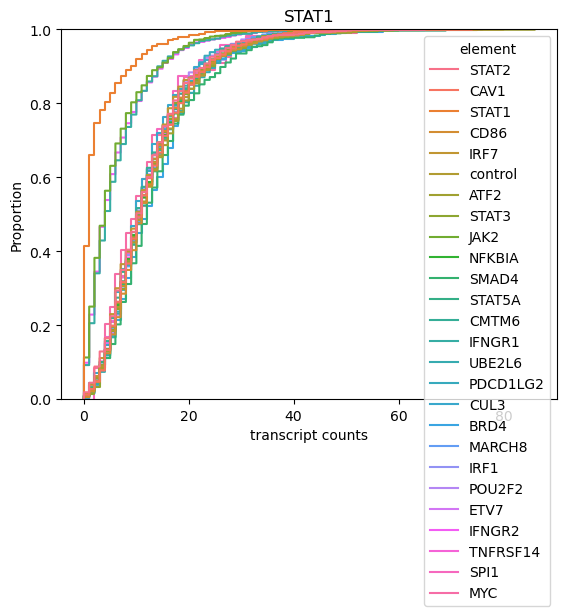

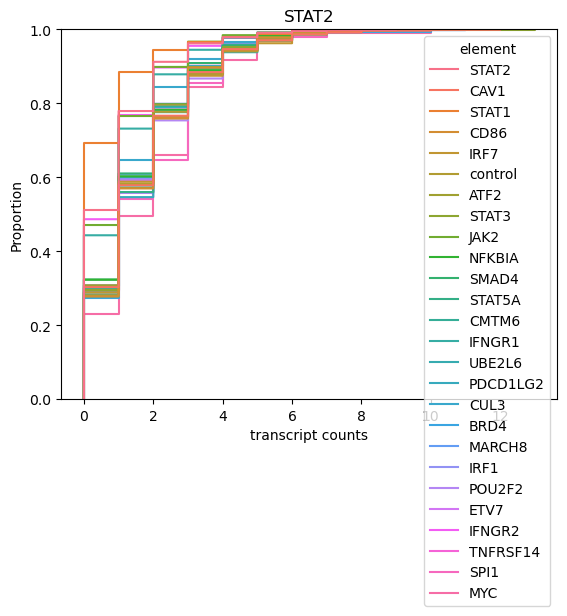

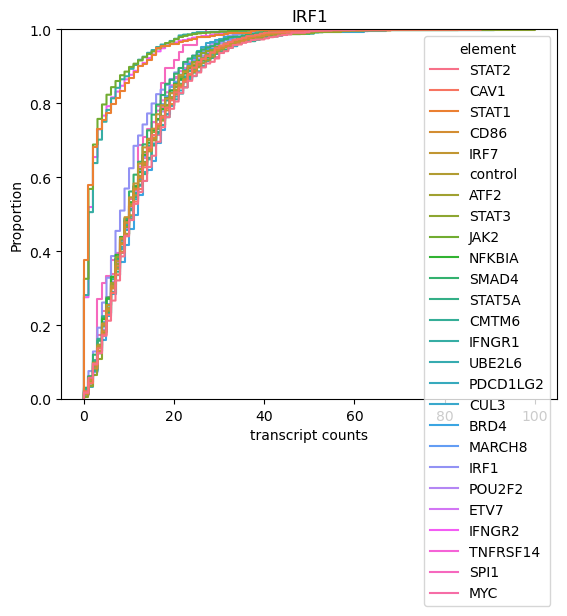

In [9]:
import seaborn as sns

# sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# counts = adata_subset[:, "IRF1"].X.todense().A1
# guide_ids = ["control"] + [f"STAT1g{i}" for i in range(1,5)]
# for guide_id in guide_ids:
# perts = adata.obs["guide_id"].str.contains(f"STAT1g{i}").values
for gene in stat_target_genes:
    counts = adata_subset[:, gene].X.todense().A1
    sns.ecdfplot(x=counts, hue=adata_subset.obs["element"])
    plt.title(gene)
    plt.xlabel("transcript counts")
    plt.show()

In [10]:
covariate_cols = ["ncounts"]
adata_subset.X.sum(axis=0).A1

array([2.33330e+05, 2.91440e+04, 2.18361e+05, 9.46400e+03, 2.00000e+00,
       3.00000e+00, 9.42400e+03, 4.45000e+03, 1.81000e+02, 1.26730e+04],
      dtype=float32)

In [35]:
# read the data to tensors
counts = torch.tensor(adata_subset.X.todense(), dtype=torch.int32)
# counts = torch.tensor(adata_subset.X.todense(), dtype=torch.int32).to_sparse()
# counts = torch.sparse_csr_tensor(adata_subset.X, dtype=torch.int32)

# perturbations = torch.tensor(
#     adata_subset.obs["perturbation"].str.replace("STAT1g", "").str.replace("control", "0").values.astype(int),
#     dtype=torch.long,
# )
guide_ids = torch.tensor(adata_subset.obs["guide_id"].values, dtype=torch.long)
element_ids = torch.tensor(adata_subset.obs["element_id"].values, dtype=torch.long)

lib_size = torch.tensor(adata_subset.obs["ncounts"].values)
size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)
gene_mean = torch.tensor(adata_subset.X.mean(axis=0).A1)
# covariates = torch.tensor(adata_subset.obs[covariate_cols].values)
# covariates = torch.hstack(torch.ones((n_cells,)), covariates)

# get data shapes
n_guides = int(guide_ids.max())
n_elements = int(element_ids.max())
n_cells, n_genes = counts.shape
# n_covariates = len(covariate_cols) + 1

print(n_guides, n_elements, n_cells, n_genes)

# print(lib_size.unsqueeze(dim=-1).log())

98 25 20729 10


/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_75897/1736998149.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)


(array([ 570., 1458., 2670., 4007., 4830., 4042., 2245.,  763.,  133.,
          11.]),
 array([-1.36212385, -1.04376841, -0.72541302, -0.40705764, -0.08870222,
         0.22965318,  0.54800856,  0.866364  ,  1.18471944,  1.50307477,
         1.82143021]),
 <BarContainer object of 10 artists>)

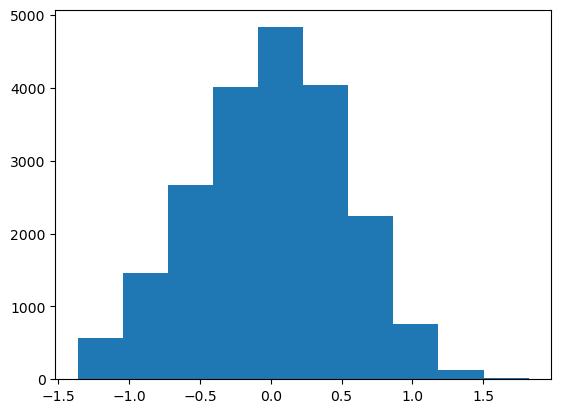

In [36]:
plt.hist(size_factor.squeeze())

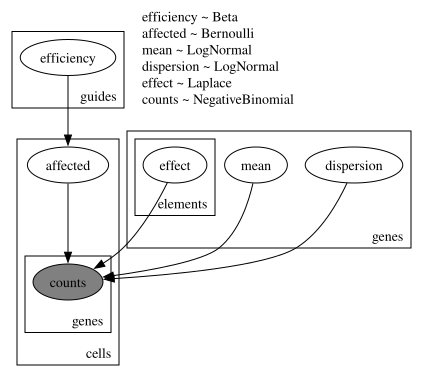

In [37]:
@config_enumerate
def model(
    counts,
    guide_ids,
    element_ids,
    n_factors=None,  # number of latent factors/confounders
    size_factor=0,  # size factor = log(lib_size) - mean(log(lib_size))
    n_genes=1,
    subsample_size=None,
):
    n_guides = int(guide_ids.max())
    n_elements = int(element_ids.max())
    if counts is not None:
        n_cells, n_genes = counts.shape
    else:
        assert guide_ids.shape == element_ids.shape
        (n_cells,) = element_ids.shape

    guides_plate = pyro.plate("guides", n_guides, dim=-2)
    elements_plate = pyro.plate("elements", n_elements, dim=-2)
    cells_plate = pyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
    genes_plate = pyro.plate("genes", n_genes, dim=-1)
    pcs_plate = pyro.plate("factors", n_factors, dim=-3)
    assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))

    if n_factors is not None:
        with cells_plate, pcs_plate:
            pcs = pyro.sample("ppc_factors", dist.Laplace(0, 1)).squeeze(dim=-1).transpose(-1, -2)  # cells x factors
        with genes_plate, pcs_plate:
            loadings = pyro.sample("ppc_loadings", dist.Laplace(0, 1)).squeeze(-2)  # factors x genes

    with guides_plate:
        efficiency = pyro.sample("efficiency", dist.Beta(9.0, 1.0))
    efficiency = torch.vstack((torch.tensor(0), efficiency))  # add dummy value for NTC guides
    # efficiency = torch.full((n_guides + 1,), efficiency)
    with cells_plate as idx:
        guide_ids = guide_ids[idx]
        affected = pyro.sample("affected", dist.Bernoulli(probs=efficiency[guide_ids], validate_args=True))
    with genes_plate:
        mean = pyro.sample("mean", dist.LogNormal(0.0, 10.0))
        dispersion = pyro.sample("dispersion", dist.LogNormal(3.0, 5.0))

        # with guides_plate:
        with elements_plate:
            effect = pyro.sample("effect", dist.Laplace(0.0, 1))
            # effect = pyro.sample("effect", dist.Normal(0.0, 3.0))
        beta = torch.vstack((torch.zeros(1, n_genes), effect))  # add dummy column for "control" element

        with cells_plate as idx:
            element_ids = element_ids[idx]
            if counts is not None and subsample_size is not None:
                counts = counts[idx, :]
            size_factor = size_factor[idx, :]
            logits = beta[element_ids, :] * affected + mean.log() + size_factor
            if n_factors is not None:
                logits += pcs @ loadings
            # obs = pyro.sample("counts", dist.Poisson(logits.exp() + epsilon), obs=counts)
            obs = pyro.sample(
                "counts",
                dist.NegativeBinomial(total_count=dispersion, logits=logits - dispersion.log()),
                obs=counts,
            )
            # obs = pyro.sample(
            #     "counts",
            #     dist.LogNormalNegativeBinomial(
            #         total_count=dispersion, logits=logits - dispersion.log(), multiplicative_noise_scale=noise
            #     ),
            #     obs=counts,
            # )
    return obs


args = (counts, guide_ids, element_ids)
kwargs = {
    "size_factor": size_factor,
    # "subsample_size": 1024,
    "n_genes": n_genes,
}
render_model(model, model_args=args, model_kwargs=kwargs, render_distributions=True)
# render_model(model, model_args=(None, perturbations), model_kwargs=kwargs)

In [60]:
guide = AutoNormal(
    poutine.block(model, hide=["affected", "counts"]),
    init_loc_fn=init_to_value(values={"mean": gene_mean}, fallback=init_to_median(num_samples=100)),
)
# elbo = TraceEnum_ELBO(max_plate_nesting=2)
elbo = JitTraceEnum_ELBO(max_plate_nesting=3)
optimizer = Adam({"lr": 0.1})
pyro.clear_param_store()

# args = (None, perturbations)
for a in args:
    if a is not None:
        print(a.shape, a.dtype)
svi = SVI(model, guide, optimizer, loss=elbo)
losses = []
for k in tqdm(range(500)):
    loss = svi.step(*args, **kwargs)
    losses.append(loss)
plt.plot(losses)

torch.Size([20729, 10]) torch.int32
torch.Size([20729]) torch.int64
torch.Size([20729]) torch.int64


  0%|          | 0/500 [00:00<?, ?it/s]/Users/ljb80/mambaforge/envs/pyro/lib/python3.10/site-packages/pyro/poutine/subsample_messenger.py:171: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if len(shape) >= -dim and shape[dim] != 1:
/Users/ljb80/mambaforge/envs/pyro/lib/python3.10/site-packages/pyro/poutine/subsample_messenger.py:171: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if len(shape) >= -dim and shape[dim] != 1:
/Users/ljb80/mambaforge/envs/pyro/lib/python3.10/site-packages/pyro/poutine/subsample_messenger.py:171: TracerWarning: Converting a t

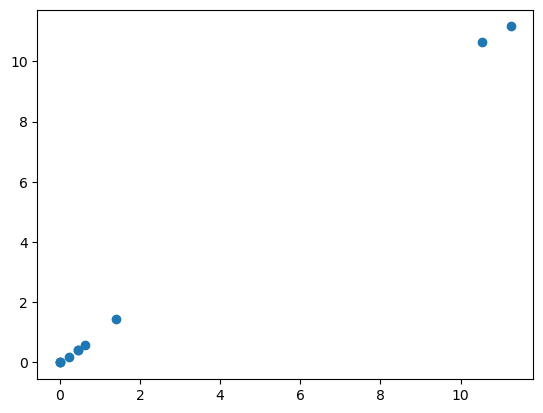

In [59]:
# sanity check: make sure gene means roughly agree with observed mean
plt.scatter(adata_subset.X.mean(axis=0).A1, guide.median()["mean"])

array([[<Axes: title={'center': 'efficiency'}>]], dtype=object)

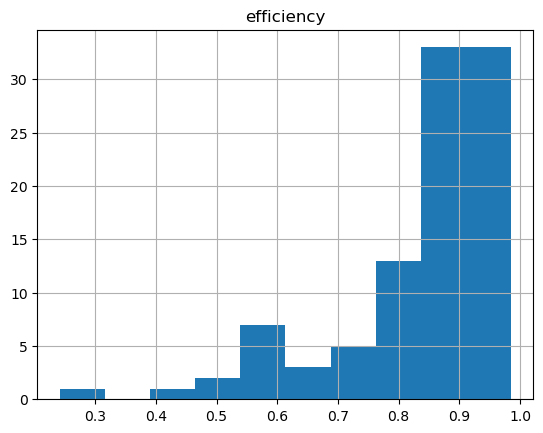

In [41]:
median_efficiency = pd.DataFrame(
    guide.median()["efficiency"], index=list(guide_mapping.keys())[:n_guides], columns=["efficiency"]
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

In [42]:
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

median_effect = guide.median()["effect"]
low_effect, high_effect = guide.quantiles([0.159, 0.841])["effect"]
sigma_effect = high_effect - low_effect
z_score_effect = median_effect / sigma_effect

effects_df = pd.DataFrame(
    z_score_effect,
    columns=adata_subset.var_names,
    index=list(element_mapping.keys())[:n_elements],
)
effects_df

gene_symbol,STAT1,STAT2,IRF1,MARCH2,RP11-282O18.3,RP11-841O20.2,C1orf106,HAUS6,PI15,APOBR
ATF2,-0.418532,-1.633022,0.274583,0.265055,-0.253129,-0.291678,-1.457543,0.472153,0.468487,-0.896259
BRD4,2.052698,-0.717872,1.734729,0.212759,0.535554,-0.045114,-1.038281,0.108270,-0.002599,-2.114178
CAV1,-0.738853,-0.439950,1.703102,0.503673,0.012400,-0.135649,0.327149,-0.477974,-0.225929,-0.534767
CD86,-0.304388,-0.528984,0.637644,-1.367408,-0.119587,-0.061059,-0.295964,0.037328,-0.076334,-1.273126
CMTM6,-2.782006,-1.647943,-0.820042,0.111248,0.032876,0.096167,-1.870208,-0.288764,-0.239422,-0.915372
CUL3,-1.609003,-1.754887,-0.478379,-1.394398,0.107327,-0.168143,-0.435439,-0.864121,-0.515389,-2.511457
ETV7,-0.659244,-0.799508,2.389592,-0.197159,-0.044707,0.086745,-2.084282,-1.695483,-0.053548,-0.722310
IFNGR1,-23.680239,-8.092217,-22.761776,-1.097736,-0.078524,0.315466,3.228108,-0.335723,0.005428,0.008085
IFNGR2,-29.145491,-11.544139,-26.217573,-1.818395,-0.058605,-0.068273,2.921426,0.767833,-0.034104,-0.969797
IRF1,0.461463,-1.437060,-4.374802,0.890728,0.002262,0.082806,-1.855826,-0.965368,-0.543533,-3.651397


In [43]:
plot_genes = list(effects_df.index)
plot_genes

['ATF2',
 'BRD4',
 'CAV1',
 'CD86',
 'CMTM6',
 'CUL3',
 'ETV7',
 'IFNGR1',
 'IFNGR2',
 'IRF1',
 'IRF7',
 'JAK2',
 'MARCH8',
 'MYC',
 'NFKBIA',
 'PDCD1LG2',
 'POU2F2',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT2',
 'STAT3',
 'STAT5A',
 'TNFRSF14',
 'UBE2L6']

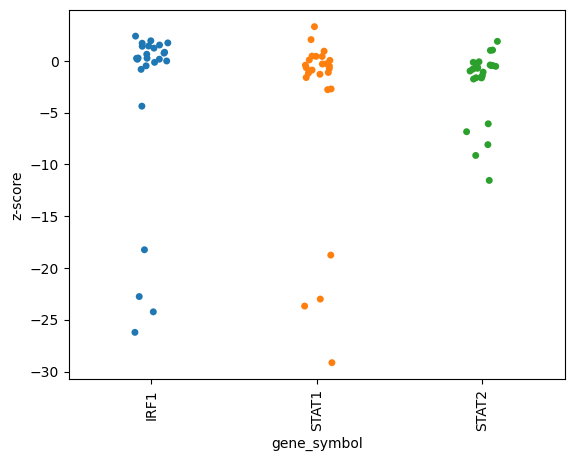

In [44]:
sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
plt.xticks(rotation=90)
plt.ylabel("z-score")
plt.show()

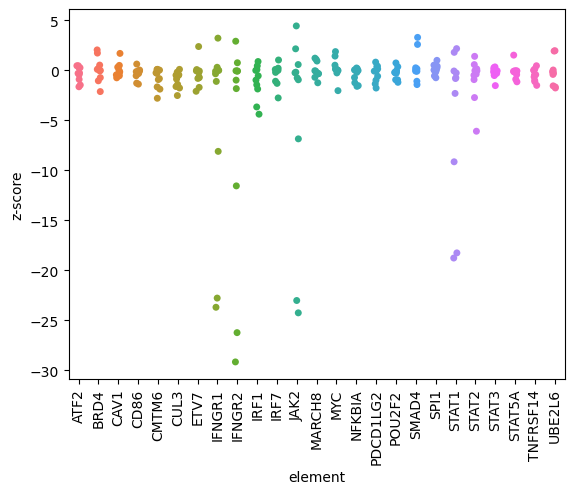

In [45]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.ylabel("z-score")
plt.xlabel("element")
plt.show()

In [46]:
alpha = 0.001
level = alpha / (n_genes*n_elements)
low, high = guide.quantiles([level, 1-level])["effect"]
(low < 0) & (high > 0)

tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True,  True,  True,  True, False],
        [ True,  True, False,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True, False,  True,  True,  True],
        [False, False, False,  True,  True,  True, False,  True,  True,  True],
        [ True,  True, False,  True,  True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True, False,  True,  True,  True],
        [False, False, False,  True,  True,  True, False,  True,  True,  True],
        [ True,  True,  True,  True,  Tr

In [47]:
guide.median()

{'efficiency': tensor([[0.8496],
         [0.8736],
         [0.9351],
         [0.9508],
         [0.9497],
         [0.9431],
         [0.7558],
         [0.7566],
         [0.9088],
         [0.9327],
         [0.9097],
         [0.9248],
         [0.8705],
         [0.9022],
         [0.9290],
         [0.8908],
         [0.5900],
         [0.5691],
         [0.5965],
         [0.5447],
         [0.5180],
         [0.9154],
         [0.8626],
         [0.7021],
         [0.9028],
         [0.9435],
         [0.7778],
         [0.5183],
         [0.8116],
         [0.5735],
         [0.7924],
         [0.6041],
         [0.6188],
         [0.5504],
         [0.2423],
         [0.9335],
         [0.8363],
         [0.8644],
         [0.8942],
         [0.8587],
         [0.8831],
         [0.9006],
         [0.6582],
         [0.7394],
         [0.7870],
         [0.8404],
         [0.8813],
         [0.8781],
         [0.9330],
         [0.8570],
         [0.9236],
         [0.9274]

In [48]:
# if "subsample_size" in kwargs:
#     kwargs.pop("subsample_size")
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals
counts_simulated = trained_model(None, guide_ids, element_ids, **kwargs)


# def classifier(args, temperature=0):
#     inferred_model = infer_discrete(
#         trained_model, temperature=temperature, first_available_dim=-3
#     )  # avoid conflict with data plate
#     trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
#     return trace.nodes["has_guide"]["value"]

adata_subset.obs["perturbation"]
# print(classifier(args))

AAACCTGAGCCAGAAC    STAT2g2
AAACCTGAGTGGACGT     CAV1g4
AAACCTGCATGAGCGA    STAT1g2
AAACCTGTCTTGTCAT     CD86g1
AAACGGGAGAACAACT     IRF7g2
                     ...   
TTTGTCAGTCACTTCC    CMTM6g1
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA     ATF2g1
TTTGTCATCACGCATA     CAV1g2
TTTGTCATCTGTACGA    STAT3g1
Name: perturbation, Length: 20729, dtype: category
Categories (99, object): ['ATF2g1', 'ATF2g2', 'ATF2g3', 'ATF2g4', ..., 'UBE2L6g2', 'UBE2L6g3', 'UBE2L6g4', 'control']

In [49]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# gene_idx = 0
# counts_simulated_col = counts_simulated[:, gene_idx]
# counts_real_col = adata_subset[:, gene_idx].X.todense().A1
# max_count = int(max(counts_simulated_col.max(), counts_real_col.max()))
# # counts_simulated_col.shape
# # perts.shape
# plot_guides = ["control"] + [f"STAT1g{i}" for i in range(1, 5)]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.scatterplot(x=counts_real_col[perts], y=counts_simulated_col[perts], label=guide_id, alpha=0.1)
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     plt.title(guide_id)
#     sns.histplot(x=counts_real_col[perts], bins=range(max_count + 1), label="real")
#     sns.histplot(x=counts_simulated_col[perts], bins=range(max_count + 1), label="simulated")
#     plt.legend()
#     plt.semilogy()
#     plt.show()

In [50]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# counts_simulated_col = counts_simulated[:, 0]
# counts_simulated_col.shape
# perts.shape
# plot_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     sns.kdeplot(x=counts_simulated_col[perts], label=guide_id)
#     # plt.show()
# plt.legend()

In [51]:
for k, v in guide.median().items():
    print (k, v.shape, v.dtype)

efficiency torch.Size([98, 1]) torch.float32
mean torch.Size([10]) torch.float32
dispersion torch.Size([10]) torch.float32
effect torch.Size([25, 10]) torch.float32


In [52]:


for a in args:
    print(a.shape, a.dtype)
for k, v in kwargs.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape, v.dtype)
    else:
        print(k,v)

torch.Size([20729, 10]) torch.int32
torch.Size([20729]) torch.int64
torch.Size([20729]) torch.int64
size_factor torch.Size([20729, 1]) torch.float32
n_genes 10


In [53]:
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals
def classifier(args, kwargs, temperature=0):
    inferred_model = infer_discrete(
        trained_model, temperature=temperature, first_available_dim=-4
    )  # avoid conflict with data plate
    trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
    return trace.nodes["affected"]["value"]

map_labels = classifier(args, kwargs, temperature=0)
map_labels
# adata_subset.obs[["perturbation"]].assign(affected=map_labels).value_counts(["perturbation", "affected"])
# x.value_counts()
# torch.mean(classifier((None, perturbations), kwargs))

tensor([[1.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [1.]])

[]

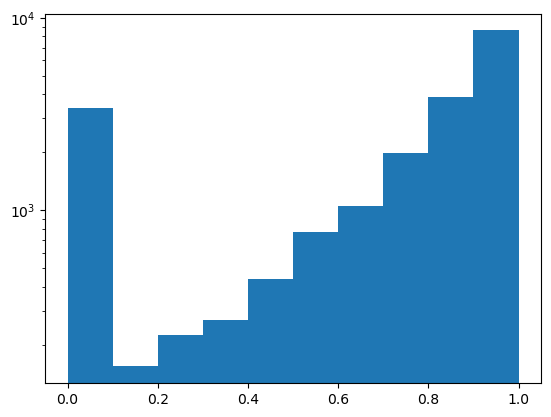

In [54]:
n_posterior_samples = 100
posterior_samples = sum(classifier(args, kwargs, temperature=1) for _ in range(n_posterior_samples))/n_posterior_samples
posterior_samples.mean()
plt.hist(posterior_samples.squeeze())
plt.semilogy()

In [55]:
tolerance = 0.01
posterior_samples[(posterior_samples<(1-tolerance)) & (posterior_samples>tolerance)]

tensor([0.9700, 0.9400, 0.6100,  ..., 0.7800, 0.9800, 0.8400])